# Работа с пропусками через Pandas

# План занятия

- Работа с пропусками через **Pandas**
- Удаление данных с пропусками через **dropna**
- Заполнение NaN на среднее/медиану/моду/константу
- Проставление меток для пропусков через **новые признаки**
- Заполнение пропусков через **группировки**
- **Интерполяция** данных
    - Линейная
    - Предыдущее/Следующее/Ближайшее значение
    - Полиномиальная

# Handling missing values Powerlifting-database

https://www.kaggle.com/datasets/open-powerlifting/powerlifting-database

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("open-powerlifting/powerlifting-database")

print("Path to dataset files:", path)

100%|██████████| 176M/176M [00:01<00:00, 147MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/open-powerlifting/powerlifting-database/versions/2


In [3]:
import os

print(os.listdir(path))

['openpowerlifting-2024-01-06-4c732975.csv', 'openpowerlifting.csv']


In [4]:
import os
import pandas as pd

csv_path = os.path.join(path, "openpowerlifting.csv")

df = pd.read_csv(csv_path)

df.head()

/tmp/ipykernel_1460/4118789303.py:6: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Squat1Kg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Country,Federation,Date,MeetCountry,MeetState,MeetName
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,F-OR,59.8,60,80.0,...,324.16,286.42,511.15,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,F-OR,58.5,60,100.0,...,378.07,334.16,595.65,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
2,Ainslee Hooper,F,B,Raw,40.0,40-44,F-OR,55.4,56,NaN,...,38.56,34.12,313.97,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,F-OR,60.0,60,-105.0,...,345.61,305.37,547.04,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,F-OR,104.0,110,120.0,...,338.91,274.56,550.08,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup


In [5]:
df = df.reset_index(drop=True)
df

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Squat1Kg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Country,Federation,Date,MeetCountry,MeetState,MeetName
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,F-OR,59.8,60,80.0,...,324.16,286.42,511.15,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,F-OR,58.5,60,100.0,...,378.07,334.16,595.65,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
2,Ainslee Hooper,F,B,Raw,40.0,40-44,F-OR,55.4,56,NaN,...,38.56,34.12,313.97,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,F-OR,60.0,60,-105.0,...,345.61,305.37,547.04,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,F-OR,104.0,110,120.0,...,338.91,274.56,550.08,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423349,Marian Cafalik,M,SBD,Raw,60.5,60-64,Masters 2,73.5,74,160.0,...,438.27,316.52,469.67,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423350,Marian Piwowarczyk,M,SBD,Raw,55.5,55-59,Masters 2,63.5,66,90.0,...,372.60,295.66,423.03,Yes,Poland,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423351,Andrzej Bryniarski,M,SBD,Raw,62.5,60-64,Masters 2,94.4,105,140.0,...,382.36,264.22,378.84,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423352,Stanisław Goroczko,M,SBD,Raw,63.5,60-64,Masters 2,80.8,83,-165.0,...,NaN,NaN,NaN,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup


In [6]:
df = df.drop_duplicates(subset=['Name'])
df.head()

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Squat1Kg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Country,Federation,Date,MeetCountry,MeetState,MeetName
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,F-OR,59.8,60,80.0,...,324.16,286.42,511.15,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,F-OR,58.5,60,100.0,...,378.07,334.16,595.65,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
2,Ainslee Hooper,F,B,Raw,40.0,40-44,F-OR,55.4,56,NaN,...,38.56,34.12,313.97,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,F-OR,60.0,60,-105.0,...,345.61,305.37,547.04,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,F-OR,104.0,110,120.0,...,338.91,274.56,550.08,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup


In [7]:
df.shape

(412574, 37)

In [8]:
df.isna().sum()

,0
Name,0
Sex,0
Event,0
Equipment,0
Age,210609
AgeClass,199524
Division,3236
BodyweightKg,5983
WeightClassKg,5016
Squat1Kg,301411


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412574 entries, 0 to 1423353
Data columns (total 37 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Name             412574 non-null  object 
 1   Sex              412574 non-null  object 
 2   Event            412574 non-null  object 
 3   Equipment        412574 non-null  object 
 4   Age              201965 non-null  float64
 5   AgeClass         213050 non-null  object 
 6   Division         409338 non-null  object 
 7   BodyweightKg     406591 non-null  float64
 8   WeightClassKg    407558 non-null  object 
 9   Squat1Kg         111163 non-null  float64
 10  Squat2Kg         110105 non-null  float64
 11  Squat3Kg         107782 non-null  float64
 12  Squat4Kg         993 non-null     float64
 13  Best3SquatKg     298882 non-null  float64
 14  Bench1Kg         157903 non-null  float64
 15  Bench2Kg         156291 non-null  float64
 16  Bench3Kg         152262 non-null  float64


In [10]:
for col in df.columns:
    print(f'{col}: {df[col].isna().sum() / df.shape[0] * 100:.2f}%')

Name: 0.00%
Sex: 0.00%
Event: 0.00%
Equipment: 0.00%
Age: 51.05%
AgeClass: 48.36%
Division: 0.78%
BodyweightKg: 1.45%
WeightClassKg: 1.22%
Squat1Kg: 73.06%
Squat2Kg: 73.31%
Squat3Kg: 73.88%
Squat4Kg: 99.76%
Best3SquatKg: 27.56%
Bench1Kg: 61.73%
Bench2Kg: 62.12%
Bench3Kg: 63.09%
Bench4Kg: 99.44%
Best3BenchKg: 10.55%
Deadlift1Kg: 71.27%
Deadlift2Kg: 71.77%
Deadlift3Kg: 72.78%
Deadlift4Kg: 99.42%
Best3DeadliftKg: 24.67%
TotalKg: 8.63%
Place: 0.00%
Wilks: 9.42%
McCulloch: 9.44%
Glossbrenner: 9.42%
IPFPoints: 11.80%
Tested: 27.76%
Country: 83.32%
Federation: 0.00%
Date: 0.00%
MeetCountry: 0.00%
MeetState: 34.14%
MeetName: 0.00%


In [11]:
df[['Age', 'Division']].head()

,Age,Division
0,29.0,F-OR
1,29.0,F-OR
2,40.0,F-OR
3,23.0,F-OR
4,45.0,F-OR


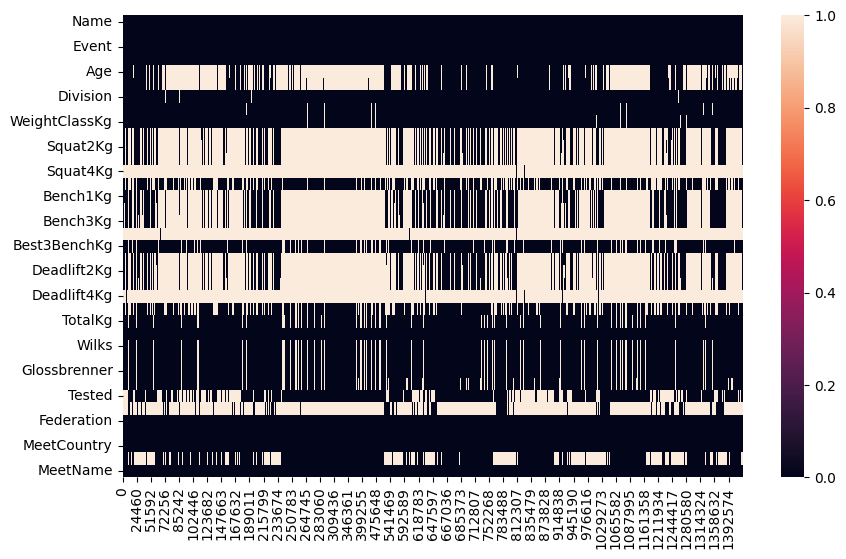

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isna().transpose());

# Удалить столбцы/строки с пропусками

In [14]:
df.shape[0]

412574

In [13]:
cols_to_drop = []

for col in df.columns:
    if df[col].isna().sum() / df.shape[0] > 0.7:
        cols_to_drop.append(col)
        
cols_to_drop

['Squat1Kg',
 'Squat2Kg',
 'Squat3Kg',
 'Squat4Kg',
 'Bench4Kg',
 'Deadlift1Kg',
 'Deadlift2Kg',
 'Deadlift3Kg',
 'Deadlift4Kg',
 'Country']

In [15]:
df.drop(columns=cols_to_drop)

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,Wilks,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,F-OR,59.80,60,105.0,...,324.16,324.16,286.42,511.15,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,F-OR,58.50,60,120.0,...,378.07,378.07,334.16,595.65,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
2,Ainslee Hooper,F,B,Raw,40.0,40-44,F-OR,55.40,56,NaN,...,38.56,38.56,34.12,313.97,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,F-OR,60.00,60,105.0,...,345.61,345.61,305.37,547.04,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,F-OR,104.00,110,140.0,...,321.25,338.91,274.56,550.08,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423345,Łukasz Głowacz,M,SBD,Raw,40.5,40-44,Masters 1,82.75,83,170.0,...,334.35,334.35,322.76,483.98,Yes,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423349,Marian Cafalik,M,SBD,Raw,60.5,60-64,Masters 2,73.50,74,175.0,...,327.07,438.27,316.52,469.67,Yes,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423351,Andrzej Bryniarski,M,SBD,Raw,62.5,60-64,Masters 2,94.40,105,160.0,...,274.48,382.36,264.22,378.84,Yes,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423352,Stanisław Goroczko,M,SBD,Raw,63.5,60-64,Masters 2,80.80,83,NaN,...,NaN,NaN,NaN,NaN,Yes,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup


## .dropna()

In [16]:
tmp = df.dropna()
tmp.shape

(3, 37)

In [17]:
tmp.isna().sum()

,0
Name,0
Sex,0
Event,0
Equipment,0
Age,0
AgeClass,0
Division,0
BodyweightKg,0
WeightClassKg,0
Squat1Kg,0


### axis

In [18]:
tmp = df.dropna(axis=1)  # defaul axis=0
tmp.shape

(412574, 9)

In [20]:
tmp.isna().sum()

,0
Name,0
Sex,0
Event,0
Equipment,0
Place,0
Federation,0
Date,0
MeetCountry,0
MeetName,0


### how

In [21]:
tmp = df.dropna(how='all', axis=0)  # defaul how='any'
tmp.shape

(412574, 37)

In [22]:
tmp = df.dropna(how='all', axis=1)  # defaul how='any'
tmp.shape

(412574, 37)

In [23]:
import numpy as np

tmp = tmp.append(pd.Series([np.nan * 16]), ignore_index=True)
tmp

AttributeError: 'DataFrame' object has no attribute 'append'

In [25]:
import numpy as np
import pandas as pd

# Dynamically generate the correct number of NaNs to match the dataframe's width
new_row = pd.DataFrame([[np.nan] * len(tmp.columns)], columns=tmp.columns)

# Concatenate the new row to the existing 'tmp' DataFrame
tmp = pd.concat([tmp, new_row], ignore_index=True)

# View the last few rows to verify
tmp.tail()

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Squat1Kg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Country,Federation,Date,MeetCountry,MeetState,MeetName
412570,Marian Cafalik,M,SBD,Raw,60.5,60-64,Masters 2,73.5,74,160.0,...,438.27,316.52,469.67,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
412571,Andrzej Bryniarski,M,SBD,Raw,62.5,60-64,Masters 2,94.4,105,140.0,...,382.36,264.22,378.84,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
412572,Stanisław Goroczko,M,SBD,Raw,63.5,60-64,Masters 2,80.8,83,-165.0,...,NaN,NaN,NaN,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
412573,Jan Sowa,M,SBD,Raw,70.5,70-74,Masters 2,82.0,83,-115.0,...,NaN,NaN,NaN,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
412574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
tmp = df.dropna(how='all', axis=0)  # defaul how='any'
tmp

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Squat1Kg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Country,Federation,Date,MeetCountry,MeetState,MeetName
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,F-OR,59.80,60,80.0,...,324.16,286.42,511.15,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,F-OR,58.50,60,100.0,...,378.07,334.16,595.65,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
2,Ainslee Hooper,F,B,Raw,40.0,40-44,F-OR,55.40,56,NaN,...,38.56,34.12,313.97,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,F-OR,60.00,60,-105.0,...,345.61,305.37,547.04,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,F-OR,104.00,110,120.0,...,338.91,274.56,550.08,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423345,Łukasz Głowacz,M,SBD,Raw,40.5,40-44,Masters 1,82.75,83,160.0,...,334.35,322.76,483.98,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423349,Marian Cafalik,M,SBD,Raw,60.5,60-64,Masters 2,73.50,74,160.0,...,438.27,316.52,469.67,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423351,Andrzej Bryniarski,M,SBD,Raw,62.5,60-64,Masters 2,94.40,105,140.0,...,382.36,264.22,378.84,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup
1423352,Stanisław Goroczko,M,SBD,Raw,63.5,60-64,Masters 2,80.80,83,-165.0,...,NaN,NaN,NaN,Yes,NaN,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup


### thresh

In [27]:
tmp.shape[0] // 2

206287

In [28]:
tmp = df.dropna(thresh=tmp.shape[0] // 2, axis=1)
tmp.shape

(412574, 23)

In [29]:
tmp.columns

Index(['Name', 'Sex', 'Event', 'Equipment', 'AgeClass', 'Division',
       'BodyweightKg', 'WeightClassKg', 'Best3SquatKg', 'Best3BenchKg',
       'Best3DeadliftKg', 'TotalKg', 'Place', 'Wilks', 'McCulloch',
       'Glossbrenner', 'IPFPoints', 'Tested', 'Federation', 'Date',
       'MeetCountry', 'MeetState', 'MeetName'],
      dtype='object')

In [30]:
df.columns

Index(['Name', 'Sex', 'Event', 'Equipment', 'Age', 'AgeClass', 'Division',
       'BodyweightKg', 'WeightClassKg', 'Squat1Kg', 'Squat2Kg', 'Squat3Kg',
       'Squat4Kg', 'Best3SquatKg', 'Bench1Kg', 'Bench2Kg', 'Bench3Kg',
       'Bench4Kg', 'Best3BenchKg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg',
       'Deadlift4Kg', 'Best3DeadliftKg', 'TotalKg', 'Place', 'Wilks',
       'McCulloch', 'Glossbrenner', 'IPFPoints', 'Tested', 'Country',
       'Federation', 'Date', 'MeetCountry', 'MeetState', 'MeetName'],
      dtype='object')

In [31]:
tmp = df.dropna(thresh=12, axis=0)
tmp.shape

(412527, 37)

In [32]:
tmp.head()

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Squat1Kg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Country,Federation,Date,MeetCountry,MeetState,MeetName
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,F-OR,59.8,60,80.0,...,324.16,286.42,511.15,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,F-OR,58.5,60,100.0,...,378.07,334.16,595.65,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
2,Ainslee Hooper,F,B,Raw,40.0,40-44,F-OR,55.4,56,NaN,...,38.56,34.12,313.97,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,F-OR,60.0,60,-105.0,...,345.61,305.37,547.04,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,F-OR,104.0,110,120.0,...,338.91,274.56,550.08,NaN,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup


### subset

In [33]:
tmp = df.dropna(subset=['Age'], axis=0)
tmp.shape

(201965, 37)

In [34]:
tmp.isna().sum()

,0
Name,0
Sex,0
Event,0
Equipment,0
Age,0
AgeClass,67
Division,1605
BodyweightKg,624
WeightClassKg,1189
Squat1Kg,116948


### inplace

In [35]:
df.shape[0] // 3

137524

In [36]:
df.dropna(thresh=df.shape[0] // 3, axis=1, inplace=True)
df.shape

/tmp/ipykernel_1460/3220595945.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(thresh=df.shape[0] // 3, axis=1, inplace=True)


(412574, 27)

In [38]:
df = df.dropna(thresh=10, axis=0)
df.shape

(412572, 27)

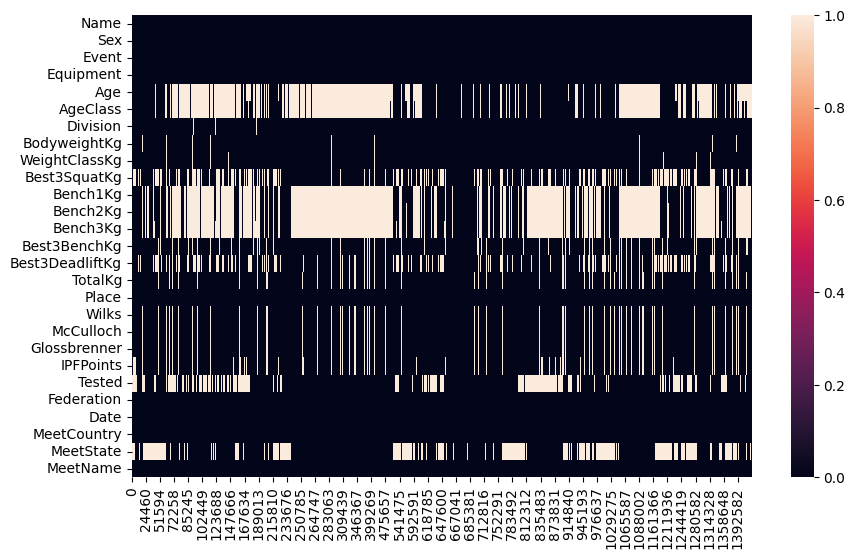

In [39]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna().transpose());

# Заполнение пропусков

## Среднее, медиана, мода

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412572 entries, 0 to 1423353
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Name             412572 non-null  object 
 1   Sex              412572 non-null  object 
 2   Event            412572 non-null  object 
 3   Equipment        412572 non-null  object 
 4   Age              201965 non-null  float64
 5   AgeClass         213050 non-null  object 
 6   Division         409338 non-null  object 
 7   BodyweightKg     406591 non-null  float64
 8   WeightClassKg    407558 non-null  object 
 9   Best3SquatKg     298882 non-null  float64
 10  Bench1Kg         157903 non-null  float64
 11  Bench2Kg         156291 non-null  float64
 12  Bench3Kg         152262 non-null  float64
 13  Best3BenchKg     369063 non-null  float64
 14  Best3DeadliftKg  310779 non-null  float64
 15  TotalKg          376979 non-null  float64
 16  Place            412572 non-null  object 


### Признак количественный

In [42]:
df['BodyweightKg'].mean()

np.float64(82.96953102749445)

In [43]:
df['BodyweightKg'].median()

81.1

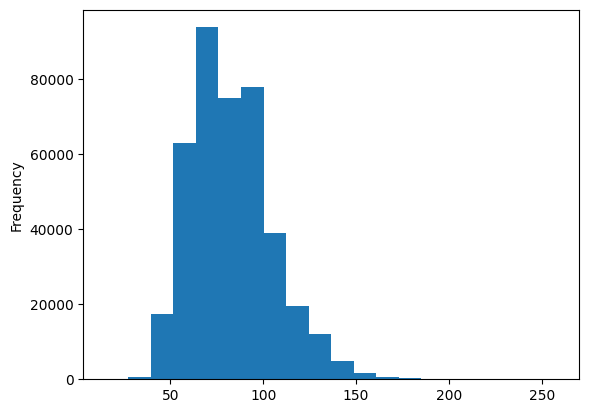

In [44]:
df['BodyweightKg'].plot(kind='hist', bins=20);

In [45]:
df['BodyweightKg'].fillna(df['BodyweightKg'].median())

,BodyweightKg
0,59.80
1,58.50
2,55.40
3,60.00
4,104.00
...,...
1423345,82.75
1423349,73.50
1423351,94.40
1423352,80.80


In [46]:
df['BodyweightKg'].isna().sum()

np.int64(5981)

In [47]:
df['BodyweightKg'] = df['BodyweightKg'].fillna(df['BodyweightKg'].median())
# df['BodyweightKg'].fillna(df['BodyweightKg'].median(), inplace=True)

In [48]:
df['BodyweightKg'].isna().sum()

np.int64(0)

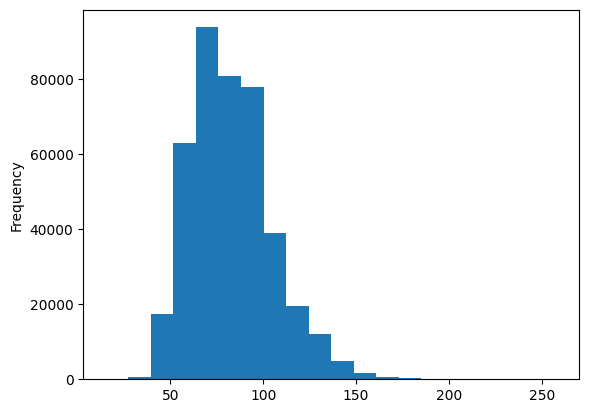

In [49]:
df['BodyweightKg'].plot(kind='hist', bins=20);

### Признак качественный

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412572 entries, 0 to 1423353
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Name             412572 non-null  object 
 1   Sex              412572 non-null  object 
 2   Event            412572 non-null  object 
 3   Equipment        412572 non-null  object 
 4   Age              201965 non-null  float64
 5   AgeClass         213050 non-null  object 
 6   Division         409338 non-null  object 
 7   BodyweightKg     412572 non-null  float64
 8   WeightClassKg    407558 non-null  object 
 9   Best3SquatKg     298882 non-null  float64
 10  Bench1Kg         157903 non-null  float64
 11  Bench2Kg         156291 non-null  float64
 12  Bench3Kg         152262 non-null  float64
 13  Best3BenchKg     369063 non-null  float64
 14  Best3DeadliftKg  310779 non-null  float64
 15  TotalKg          376979 non-null  float64
 16  Place            412572 non-null  object 


In [51]:
df['Division'].value_counts()

,count
Division,
Open,101017
Boys,65510
Girls,23693
Juniors,17300
MR-O,10360
...,...
Paralympic,1
Amateur Youth 10,1
M-M8R,1


In [54]:
df['Division'] = df['Division'].str.lower()

df['Division'].value_counts()

,count
Division,
open,101400
boys,65510
girls,23693
juniors,17300
mr-o,10360
...,...
pro teen (18-19),1
police pro submasters 33-39,1
police amateur submasters 33-39,1


In [53]:
df['Division'].mode()

,Division
0,open


In [55]:
df['Division'] = df['Division'].fillna(df['Division'].mode())
df['Division'].isna().sum()

np.int64(3234)

In [56]:
division_mode = df['Division'].mode().iloc[0]
division_mode

'open'

In [57]:
df['Division'] = df['Division'].fillna(division_mode)
df['Division'].isna().sum()

np.int64(0)

## Indicator

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412572 entries, 0 to 1423353
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Name             412572 non-null  object 
 1   Sex              412572 non-null  object 
 2   Event            412572 non-null  object 
 3   Equipment        412572 non-null  object 
 4   Age              201965 non-null  float64
 5   AgeClass         213050 non-null  object 
 6   Division         412572 non-null  object 
 7   BodyweightKg     412572 non-null  float64
 8   WeightClassKg    407558 non-null  object 
 9   Best3SquatKg     298882 non-null  float64
 10  Bench1Kg         157903 non-null  float64
 11  Bench2Kg         156291 non-null  float64
 12  Bench3Kg         152262 non-null  float64
 13  Best3BenchKg     369063 non-null  float64
 14  Best3DeadliftKg  310779 non-null  float64
 15  TotalKg          376979 non-null  float64
 16  Place            412572 non-null  object 


In [59]:
df['Place'].value_counts()

,count
Place,
1,143293
2,61537
3,39444
DQ,32018
4,28125
...,...
94,1
101,1
92,1


In [60]:
df['Place_nan'] = 0
df.head()

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,f-or,59.8,60,105.0,...,324.16,286.42,511.15,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,f-or,58.5,60,120.0,...,378.07,334.16,595.65,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
2,Ainslee Hooper,F,B,Raw,40.0,40-44,f-or,55.4,56,NaN,...,38.56,34.12,313.97,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,f-or,60.0,60,105.0,...,345.61,305.37,547.04,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,f-or,104.0,110,140.0,...,338.91,274.56,550.08,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0


In [61]:
df.loc[df['Place'].isna(), 'Place_nan'] = 1
df[df['Place'].isna()].head()

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan


In [62]:
df['Place_nan'].value_counts()

,count
Place_nan,
0,412572


In [63]:
df['Place'].isna().sum()

np.int64(0)

In [64]:
df['Place'].fillna(0, inplace=True)
df['Place'].isna().sum()

/tmp/ipykernel_1460/586890117.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Place'].fillna(0, inplace=True)


np.int64(0)

In [65]:
df[df['Place_nan'] == 1].head()

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan


## Неизвестность 

In [66]:
df['WeightClassKg'].value_counts()

,count
WeightClassKg,
90,32425
75,31943
82.5,29706
100,28936
67.5,23084
...,...
75.5,1
100.2,1
136.5+,1


In [67]:
df['WeightClassKg'].fillna('Unknown', inplace=True)

df.isna().sum()

/tmp/ipykernel_1460/1199767507.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['WeightClassKg'].fillna('Unknown', inplace=True)


,0
Name,0
Sex,0
Event,0
Equipment,0
Age,210607
AgeClass,199522
Division,0
BodyweightKg,0
WeightClassKg,0
Best3SquatKg,113690


## Более умное заполнение средними/медианами/модами

In [68]:
df['Age'].isna().sum()

np.int64(210607)

In [69]:
df.groupby('Division')['Age'].median()

,Age
Division,
0/60,NaN
1-f_mcr_2_aapf,45.00
1-f_mr_2_aapf,47.00
1-f_or_aapf,25.00
1-f_tr_1_aapf,12.00
...,...
т 18-19,18.00
т18-19,18.00
ю 20-23,21.00


In [70]:
df[df['Division'] == 'м1 40-49']

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan
796923,Vladimir Gavrish,M,SBD,Wraps,NaN,NaN,м1 40-49,80.9,82.5,185.0,...,352.53,340.47,514.93,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
796961,Konstantin Udalov,M,SBD,Wraps,NaN,NaN,м1 40-49,93.0,100,230.0,...,395.76,381.09,584.61,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
796962,Oleg Usatenko,M,SBD,Wraps,NaN,NaN,м1 40-49,99.5,100,220.0,...,359.79,345.84,519.09,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
796983,Anatoliy Andreev,M,SBD,Wraps,NaN,NaN,м1 40-49,122.3,125,190.0,...,303.41,289.30,402.99,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
797027,Nurzhan Zhalpakov,M,B,Raw,NaN,NaN,м1 40-49,66.3,67.5,NaN,...,89.96,87.31,555.64,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
797045,Anatoliy Dorokhov,M,B,Raw,NaN,NaN,м1 40-49,73.5,75,NaN,...,108.42,104.92,667.50,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
797072,Masimzhan Ismailov,M,B,Raw,46.5,45-49,м1 40-49,80.6,82.5,NaN,...,119.74,108.29,685.43,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
797074,Vladimir Ashchepkov,M,B,Raw,NaN,NaN,м1 40-49,80.0,82.5,NaN,...,95.58,92.33,584.58,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
797117,Igor Maksimov,M,B,Raw,41.5,40-44,м1 40-49,99.4,100,NaN,...,83.18,79.17,487.18,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0
797136,Aleksandr Mikhaelis,M,B,Raw,NaN,NaN,м1 40-49,107.0,110,NaN,...,112.81,108.17,655.33,NaN,WRPF,2017-04-29,Kazakhstan,NaN,Asian Championship,0


In [71]:
age_by_division = df.groupby('Division')['Age'].transform('median')
age_by_division

,Age
0,29.0
1,29.0
2,29.0
3,29.0
4,29.0
...,...
1423345,43.5
1423349,52.5
1423351,52.5
1423352,52.5


In [72]:
df[df['Age'].isna()]

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan
106,Tim Plummer,M,SBD,Wraps,NaN,NaN,m-or,109.50,110,165.0,...,279.93,268.20,377.35,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
640,Mike Read,M,SBD,Wraps,NaN,NaN,m-or,120.90,125,190.0,...,308.49,294.31,412.69,NaN,GPC-AUS,2013-04-28,Australia,VIC,Victoria Qualifier,0
641,Mike V,M,SBD,Wraps,NaN,NaN,m-or,132.50,140,100.0,...,NaN,NaN,NaN,NaN,GPC-AUS,2013-04-28,Australia,VIC,Victoria Qualifier,0
908,Alexandra Hegman,F,SBD,Wraps,NaN,NaN,f-or,63.20,67.5,120.0,...,345.52,305.09,556.19,NaN,GPC-AUS,2017-09-09,Australia,VIC,Melbourne Cup,0
2073,Daniel Kindilas,M,SBD,Wraps,NaN,NaN,m-or,109.05,110,NaN,...,NaN,NaN,NaN,NaN,GPC-AUS,2017-10-22,Australia,NSW,Sydney Cup,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423251,Michał Kowalczyk,M,SBD,Raw,NaN,NaN,juniors under 16,79.20,83,175.0,...,307.47,297.07,438.12,Yes,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup,0
1423253,Norbert Kaczor,M,SBD,Raw,NaN,NaN,juniors under 16,84.40,93,137.5,...,262.75,253.55,362.06,Yes,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup,0
1423254,Daniel Machulik,M,SBD,Raw,NaN,NaN,juniors under 16,83.30,93,115.0,...,246.45,237.88,334.43,Yes,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup,0
1423255,Jakub Ostrowski,M,SBD,Raw,NaN,NaN,juniors under 16,73.00,74,110.0,...,243.33,235.52,327.50,Yes,PZKFiTS,2017-04-01,Poland,NaN,Polish Classic Powerlifting Cup,0


In [73]:
df[df['Division'] == 'lm 65-69']

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan
137819,James Mathews,M,BD,Raw,NaN,NaN,lm 65-69,67.50,67.5,NaN,...,192.75,186.97,NaN,Yes,AAU,2003-09-21,USA,CA,Drug Free National Bench Press Deadlift & Push...,0
176464,Valerie Silver,F,SBD,Raw,69.0,65-69,lm 65-69,57.65,60,60.0,...,393.49,216.07,374.21,Yes,AAU,2018-09-28,USA,NV,World Championships,0
176501,Jean Dawkins,F,BD,Raw,65.0,65-69,lm 65-69,50.21,52,NaN,...,260.59,156.31,NaN,Yes,AAU,2018-09-28,USA,NV,World Championships,0
176530,Robert Bienvenu,M,B,Single-ply,69.0,65-69,lm 65-69,82.10,82.5,NaN,...,78.42,47.03,322.28,Yes,AAU,2018-09-28,USA,NV,World Championships,0
177479,Faith Ireland,F,SBD,Raw,67.0,65-69,lm 65-69,62.23,67.5,75.0,...,380.53,217.80,389.90,Yes,AAU,2010-10-08,USA,NV,World Championships,0
177554,Merv Goldstein,M,B,Raw,69.0,65-69,lm 65-69,82.28,82.5,NaN,...,140.98,84.54,533.98,Yes,AAU,2010-10-08,USA,NV,World Championships,0
177577,Martin Montgomery,M,D,Single-ply,67.0,65-69,lm 65-69,74.39,75,NaN,...,232.21,145.60,497.72,Yes,AAU,2010-10-08,USA,NV,World Championships,0
178206,Bob Hartshorne,M,B,Raw,65.0,65-69,lm 65-69,110.00,110,NaN,...,113.23,73.29,441.31,Yes,AAU,2004-06-20,USA,NaN,North Americans,0
178936,Robert Bienvienu,M,B,Single-ply,67.0,65-69,lm 65-69,82.19,82.5,NaN,...,85.47,53.48,345.33,Yes,AAU,2016-09-23,USA,NV,Worlds,0
180032,Leon McCrary,M,SBD,Single-ply,67.0,65-69,lm 65-69,75.00,75,130.0,...,401.31,251.58,352.17,Yes,AAU,2004-12-01,USA,NaN,World Powerlifting & International Bench Press...,0


In [74]:
idx = 137819

In [75]:
age_by_division.loc[idx]

np.float64(67.0)

In [76]:
df['Age'] = df['Age'].fillna(age_by_division)
df.head()

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,f-or,59.8,60,105.0,...,324.16,286.42,511.15,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,f-or,58.5,60,120.0,...,378.07,334.16,595.65,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
2,Ainslee Hooper,F,B,Raw,40.0,40-44,f-or,55.4,56,NaN,...,38.56,34.12,313.97,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,f-or,60.0,60,105.0,...,345.61,305.37,547.04,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,f-or,104.0,110,140.0,...,338.91,274.56,550.08,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0


In [77]:
df.loc[[idx]]

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,McCulloch,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan
137819,James Mathews,M,BD,Raw,67.0,NaN,lm 65-69,67.5,67.5,NaN,...,192.75,186.97,NaN,Yes,AAU,2003-09-21,USA,CA,Drug Free National Bench Press Deadlift & Push...,0


In [78]:
df['Age'].isna().sum()

np.int64(2197)

In [79]:
division_missing_age = df[df['Age'].isna()]['Division'].value_counts()
division_missing_age

,count
Division,
fr/soph,156
below class ii,113
police amateur open,93
div 3,82
m-c-u20,73
...,...
amateur masters 50+,1
0/60,1
law/fire open,1


In [80]:
division_missing_age_df = division_missing_age.index.str.extract('(\d\d)-(\d\d)|(\d\d)')
division_missing_age_df

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1460/280752259.py:1: SyntaxWarning: invalid escape sequence '\d'
  division_missing_age_df = division_missing_age.index.str.extract('(\d\d)-(\d\d)|(\d\d)')


,0,1,2
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,20
...,...,...,...
507,NaN,NaN,50
508,NaN,NaN,60
509,NaN,NaN,NaN
510,40,46,NaN


In [81]:
division_missing_age_df['Division'] = division_missing_age.index
division_missing_age_df

,0,1,2,Division
0,NaN,NaN,NaN,fr/soph
1,NaN,NaN,NaN,below class ii
2,NaN,NaN,NaN,police amateur open
3,NaN,NaN,NaN,div 3
4,NaN,NaN,20,m-c-u20
...,...,...,...,...
507,NaN,NaN,50,amateur masters 50+
508,NaN,NaN,60,0/60
509,NaN,NaN,NaN,law/fire open
510,40,46,NaN,law/fire masters 40-46


In [82]:
def count_mean(x):
    if not x[0] is np.nan:
        return (int(x[0]) + int(x[1])) / 2
    elif not x[2] is np.nan:
        return x[2]
    else:
        return np.nan
    
division_missing_age_df['mean'] = division_missing_age_df.apply(count_mean, axis=1)
division_missing_age_df

,0,1,2,Division,mean
0,NaN,NaN,NaN,fr/soph,NaN
1,NaN,NaN,NaN,below class ii,NaN
2,NaN,NaN,NaN,police amateur open,NaN
3,NaN,NaN,NaN,div 3,NaN
4,NaN,NaN,20,m-c-u20,20
...,...,...,...,...,...
507,NaN,NaN,50,amateur masters 50+,50
508,NaN,NaN,60,0/60,60
509,NaN,NaN,NaN,law/fire open,NaN
510,40,46,NaN,law/fire masters 40-46,43.0


In [83]:
division_missing_age_df['mean'].isna().sum()

np.int64(316)

In [84]:
df = df.merge(division_missing_age_df[['Division', 'mean']], on='Division', how='left')
df.head()

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan,mean
0,Abbie Murphy,F,SBD,Wraps,29.0,24-34,f-or,59.8,60,105.0,...,286.42,511.15,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0,NaN
1,Abbie Tuong,F,SBD,Wraps,29.0,24-34,f-or,58.5,60,120.0,...,334.16,595.65,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0,NaN
2,Ainslee Hooper,F,B,Raw,40.0,40-44,f-or,55.4,56,NaN,...,34.12,313.97,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0,NaN
3,Amy Moldenhauer,F,SBD,Wraps,23.0,20-23,f-or,60.0,60,105.0,...,305.37,547.04,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0,NaN
4,Andrea Rowan,F,SBD,Wraps,45.0,45-49,f-or,104.0,110,140.0,...,274.56,550.08,NaN,GPC-AUS,2018-10-27,Australia,VIC,Melbourne Cup,0,NaN


In [85]:
mean_age_by_division = df.groupby('Division')['mean'].transform('mean')
mean_age_by_division

TypeError: agg function failed [how->mean,dtype->object]

In [86]:
# 1. Преобразуем столбец 'mean' в числовой формат.
# Параметр errors='coerce' аккуратно превратит любой нечитаемый текст в NaN (пропуски)
df['mean'] = pd.to_numeric(df['mean'], errors='coerce')

# 2. Запускаем ваш исходный код снова
mean_age_by_division = df.groupby('Division')['mean'].transform('mean')
mean_age_by_division

,mean
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
412567,NaN
412568,NaN
412569,NaN
412570,NaN


In [87]:
df[df['Division'] == 'teen 14-18']

,Name,Sex,Event,Equipment,Age,AgeClass,Division,BodyweightKg,WeightClassKg,Best3SquatKg,...,Glossbrenner,IPFPoints,Tested,Federation,Date,MeetCountry,MeetState,MeetName,Place_nan,mean
180616,Suzanne Svanevik,F,SBD,Raw,17.5,NaN,teen 14-18,55.7,57,100.0,...,292.67,509.54,Yes,NSF,2013-08-03,Norway,NaN,Klubbstevne,0,NaN
180620,Hugo Kjellemo,M,SB,Single-ply,17.5,NaN,teen 14-18,70.7,75,157.5,...,176.51,NaN,Yes,NSF,1989-10-27,Norway,NaN,Seriestevne,0,NaN
180624,Anna Nafisa Hjelle Skjenken,F,SBD,Raw,17.5,NaN,teen 14-18,56.3,57,70.0,...,235.76,406.58,Yes,NSF,2016-03-12,Norway,NaN,Åpent stevne styrkeløft utstyrsfritt,0,NaN
180643,Kim Aarskog Vestly,M,SBD,Raw,17.5,NaN,teen 14-18,62.5,66,100.0,...,239.95,326.12,Yes,NSF,2018-06-09,Norway,NaN,Klubbstevne,0,NaN
180644,Josia Saffaran,M,SBD,Raw,17.5,NaN,teen 14-18,62.8,66,85.0,...,222.98,297.38,Yes,NSF,2018-06-09,Norway,NaN,Klubbstevne,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185320,Lars Terje Bjørsvik,M,SBD,Single-ply,17.5,NaN,teen 14-18,51.7,52,75.0,...,203.77,294.38,Yes,NSF,1991-12-21,Norway,NaN,Julestevne,0,NaN
185324,Kamilla Bedin,F,SBD,Single-ply,17.5,NaN,teen 14-18,65.4,72,102.5,...,258.08,408.29,Yes,NSF,2012-12-15,Norway,NaN,Klubbstevne,0,NaN
185327,Kristian Bustgaard Marsell,M,B,Raw,17.5,NaN,teen 14-18,82.7,83,NaN,...,64.90,409.56,Yes,NSF,2016-02-26,Norway,NaN,Klubbstevne,0,NaN
185328,Didrik Soløy,M,SBD,Raw,17.5,NaN,teen 14-18,102.0,105,165.0,...,291.48,422.70,Yes,NSF,2016-02-26,Norway,NaN,Klubbstevne,0,NaN


In [90]:
mean_age_by_division.loc[180616]

np.float64(nan)

In [91]:
df['Age'] = df['Age'].fillna(mean_age_by_division)
df['Age'].isna().sum()

np.int64(1603)

In [92]:
division_missing_age = df[df['Age'].isna()]['Division'].value_counts()
division_missing_age

,count
Division,
fr/soph,156
below class ii,113
police amateur open,93
div 3,82
smp,60
...,...
r m,1
masters2,1
especiales,1


In [93]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412572 entries, 0 to 412571
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Name             412572 non-null  object 
 1   Sex              412572 non-null  object 
 2   Event            412572 non-null  object 
 3   Equipment        412572 non-null  object 
 4   Age              412572 non-null  float64
 5   AgeClass         213050 non-null  object 
 6   Division         412572 non-null  object 
 7   BodyweightKg     412572 non-null  float64
 8   WeightClassKg    412572 non-null  object 
 9   Best3SquatKg     298882 non-null  float64
 10  Bench1Kg         157903 non-null  float64
 11  Bench2Kg         156291 non-null  float64
 12  Bench3Kg         152262 non-null  float64
 13  Best3BenchKg     369063 non-null  float64
 14  Best3DeadliftKg  310779 non-null  float64
 15  TotalKg          376979 non-null  float64
 16  Place            412572 non-null  obje

In [95]:
df.drop(columns='mean', inplace=True)

KeyError: "['mean'] not found in axis"

## Интерполировать

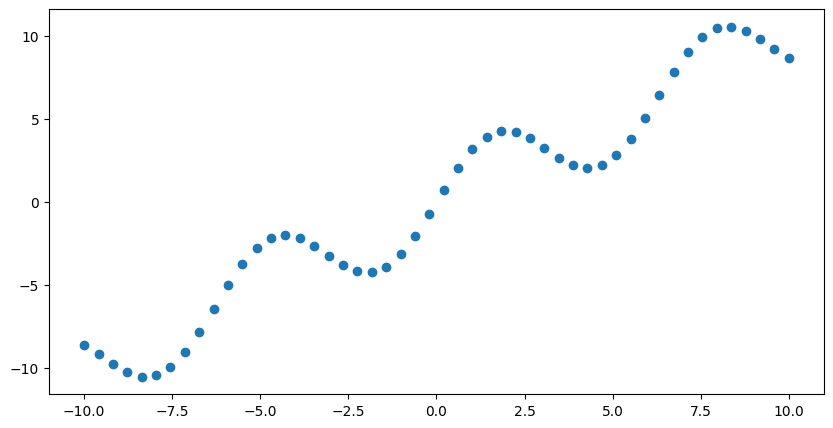

In [96]:
x = np.linspace(-10, 10, num=50)
y = 2.5 * np.sin(x) + x

plt.figure(figsize=(10, 5))
plt.scatter(x, y);

In [97]:
df = pd.DataFrame({'x': x, 'true_y': y})
df

,x,true_y
0,-10.000000,-8.639947
1,-9.591837,-9.176130
2,-9.183673,-9.780612
3,-8.775510,-10.287018
4,-8.367347,-10.545089
5,-7.959184,-10.445362
6,-7.551020,-9.937163
7,-7.142857,-9.036928
8,-6.734694,-7.825502
9,-6.326531,-6.434860


In [98]:
np.random.seed(9)

df['y'] = df['true_y']
df.loc[np.random.randint(0, 50, 10), 'y'] = np.nan
df.head()

,x,true_y,y
0,-10.000000,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN
2,-9.183673,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089


In [99]:
nan_x = df[df['y'].isna()]['x']
nan_y = df[df['y'].isna()]['true_y']

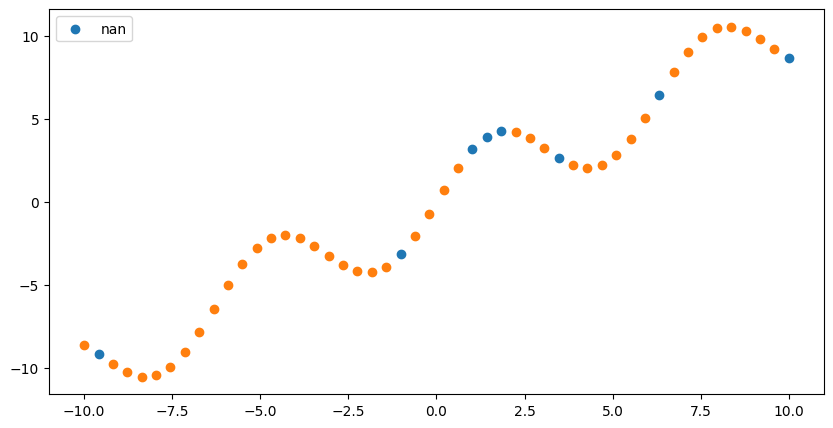

In [100]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y'])
plt.legend();

### linear interpolation

In [101]:
df['y_lin'] = df['y'].interpolate()
df.head()

,x,true_y,y,y_lin
0,-10.000000,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279
2,-9.183673,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089


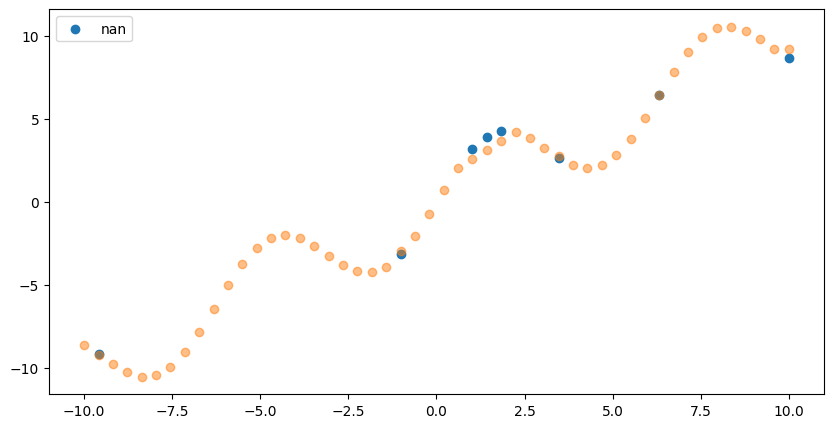

In [102]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_lin'], alpha=0.5)
plt.legend();

In [103]:
np.mean(np.abs(df['true_y'] - df['y_lin']))

np.float64(0.05506338361659317)

### padding

In [104]:
df['y_pad'] = df['y'].interpolate(method='pad', limit=2)
df.head()

/tmp/ipykernel_1460/3845021345.py:1: FutureWarning: Series.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['y_pad'] = df['y'].interpolate(method='pad', limit=2)


,x,true_y,y,y_lin,y_pad
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089


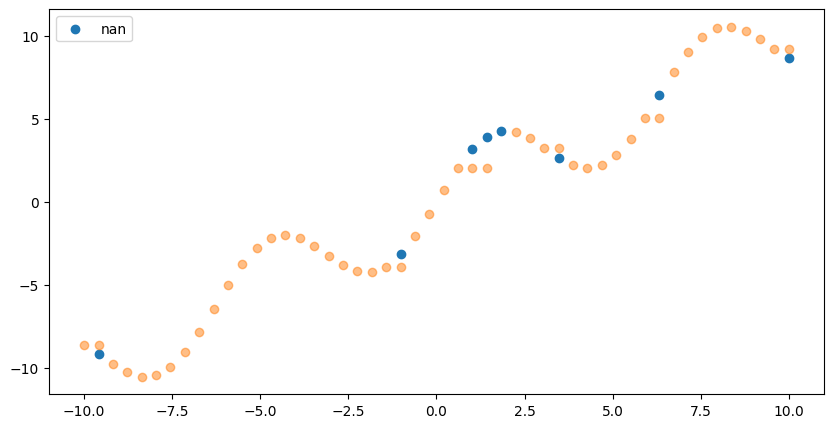

In [105]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_pad'], alpha=0.5)
plt.legend();

In [106]:
np.mean(np.abs(df['true_y'] - df['y_pad']))

np.float64(0.1385076673888301)

In [107]:
df['y_pad_fillna'] = df['y']
df['y_pad_fillna'] = df['y_pad_fillna'].fillna(method="pad")
df.head()

/tmp/ipykernel_1460/617870886.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['y_pad_fillna'] = df['y_pad_fillna'].fillna(method="pad")


,x,true_y,y,y_lin,y_pad,y_pad_fillna
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947,-8.639947
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089


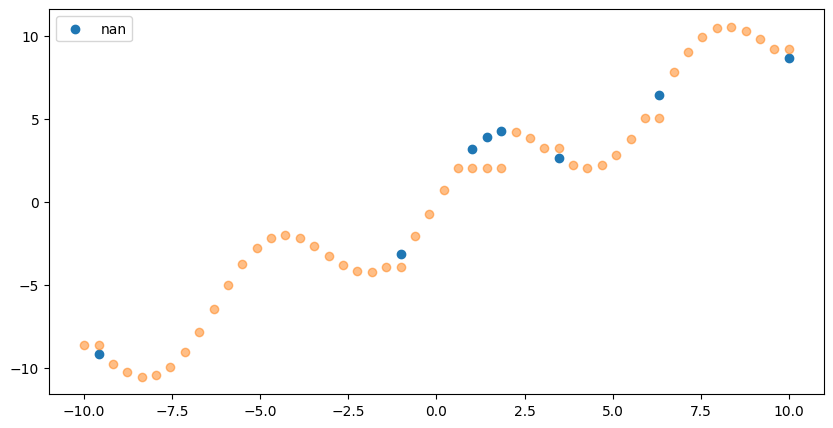

In [108]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_pad_fillna'], alpha=0.5)
plt.legend();

In [109]:
np.mean(np.abs(df['true_y'] - df['y_pad_fillna']))

np.float64(0.1797343233478001)

In [110]:
df['y_bfill'] = df['y']
df['y_bfill'] = df['y_bfill'].fillna(method="bfill")
df.head()

/tmp/ipykernel_1460/556921745.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['y_bfill'] = df['y_bfill'].fillna(method="bfill")


,x,true_y,y,y_lin,y_pad,y_pad_fillna,y_bfill
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947,-8.639947,-9.780612
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089


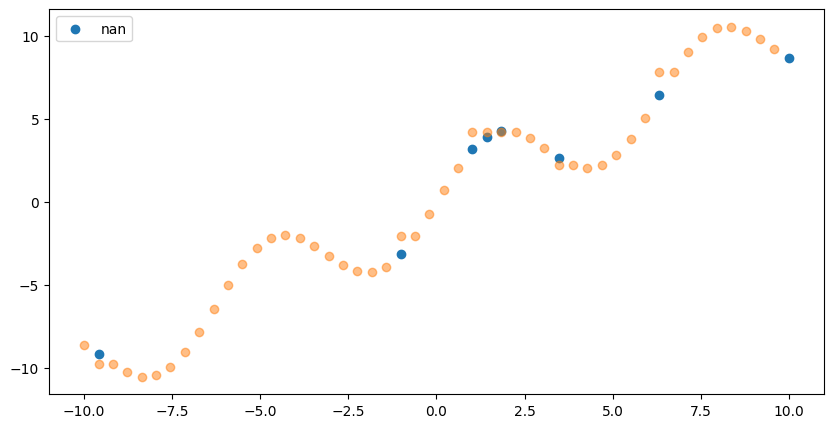

In [111]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_bfill'], alpha=0.5)
plt.legend();

In [112]:
np.mean(np.abs(df['true_y'] - df['y_bfill']))

np.float64(0.10112029186156916)

### nearest

In [113]:
df['y_nearest'] = df['y'].interpolate(method='nearest')
df.head()

,x,true_y,y,y_lin,y_pad,y_pad_fillna,y_bfill,y_nearest
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947,-8.639947,-9.780612,-8.639947
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089


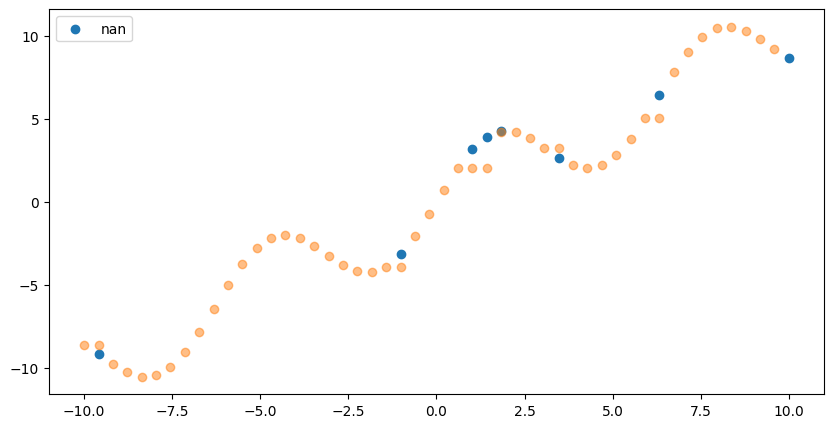

In [114]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_nearest'], alpha=0.5)
plt.legend();

In [115]:
np.mean(np.abs(df['true_y'] - df['y_nearest']))

np.float64(0.12860154332846715)

### polynomial

In [116]:
df['y_poly'] = df['y'].interpolate(method='polynomial', order=2)
df.head()

,x,true_y,y,y_lin,y_pad,y_pad_fillna,y_bfill,y_nearest,y_poly
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947,-8.639947,-9.780612,-8.639947,-9.221393
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089


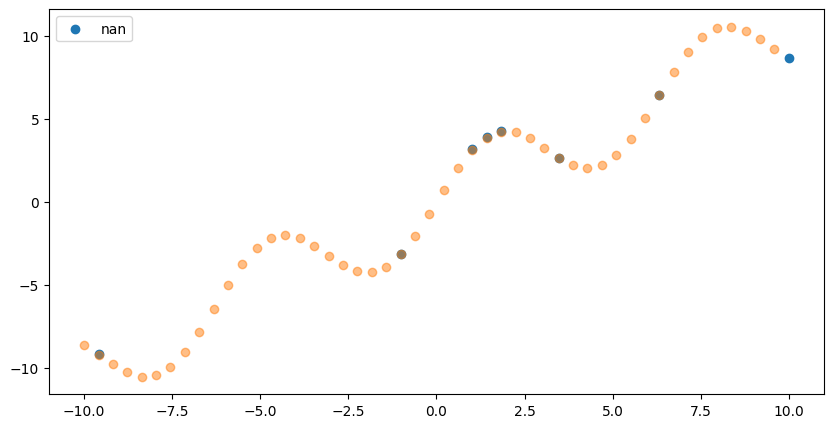

In [117]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_poly'], alpha=0.5)
plt.legend();

In [118]:
np.mean(np.abs(df['true_y'] - df['y_poly']))

np.float64(0.004505216798914928)

# Что сегодня узнали:
- Как работать с пропусками через **Pandas**
- Как удалять данные с пропусками через **dropna**
- Как заполнять NaN на среднее/медиану/моду/константу
- Как помечать пропуски через **новые признаки**
- Как заполнять пропуски через **группировки**
- Как **интерполировать** данные
    - Линейная
    - Предыдущее/Следующее/Ближайшее значение
    - Полиномиальная

**Муррр** ♥